In [ ]:
!pip uninstall -y numpy
!pip install numpy==1.26.4 --force-reinstall --no-cache-dir
!pip install --no-cache-dir -U matplotlib==3.9.2 scikit-learn==1.5.2 ultralytics==8.3.16

In [1]:
import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import precision_score, recall_score, f1_score, hamming_loss, precision_recall_curve, accuracy_score
from sklearn.multiclass import OneVsRestClassifier

from lightgbm import LGBMClassifier
from collections import Counter
from ultralytics import YOLO

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda


In [2]:
df = pd.read_csv("/kaggle/input/poster/MovieGenre.csv", encoding='latin1')
print(df.isnull().sum())

imdbId          0
Imdb Link       0
Title           0
IMDB Score     48
Genre         145
Poster        725
dtype: int64


In [3]:
df = df.dropna(subset=["Genre", "Poster"]).copy()
df["Genre"] = df["Genre"].apply(lambda x: [g.strip() for g in str(x).split("|")])

poster_dir = "/kaggle/input/poster/Posters"

def is_valid_image(path):
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except:
        return False

df = df[df["imdbId"].apply(lambda x: is_valid_image(os.path.join(poster_dir, f"{x}.jpg")))]
df = df.reset_index(drop=True)
print("Số ảnh hợp lệ:", len(df))

Số ảnh hợp lệ: 39140


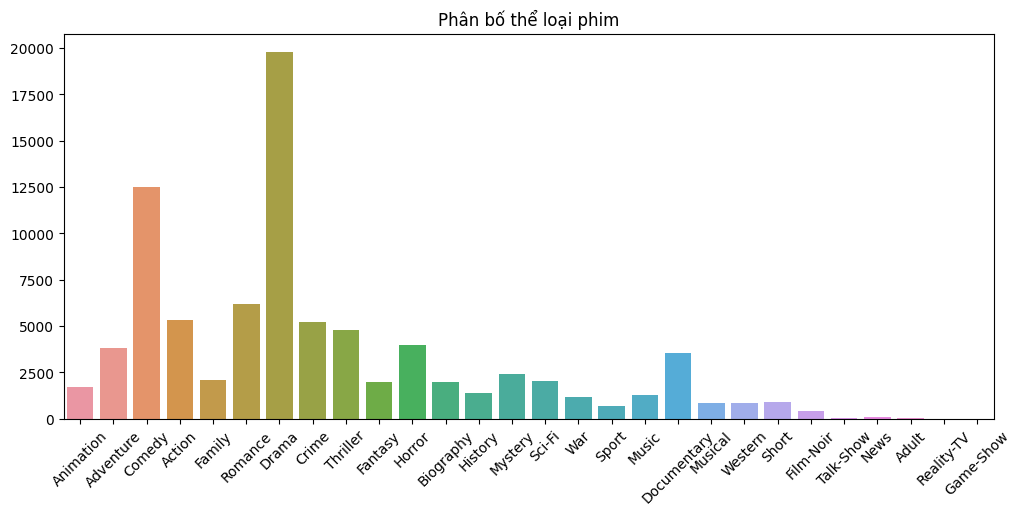

In [4]:
genre_count = Counter([g for sublist in df["Genre"] for g in sublist])
plt.figure(figsize=(12,5))
sns.barplot(x=list(genre_count.keys()), y=list(genre_count.values()))
plt.xticks(rotation=45)
plt.title("Phân bố thể loại phim")
plt.show()

Số thể loại trung bình mỗi phim: 2.1676801226366886


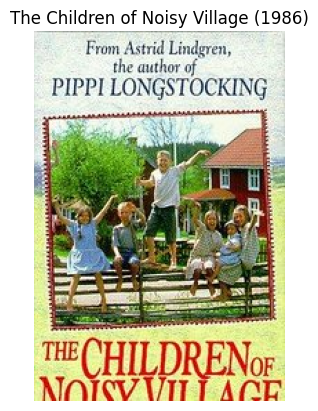

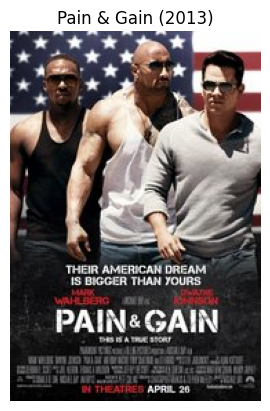

In [5]:
df["num_genres"] = df["Genre"].apply(len)
print("Số thể loại trung bình mỗi phim:", df["num_genres"].mean())

sample_df = df.sample(2)
for _, row in sample_df.iterrows():
    img_path = os.path.join(poster_dir, f"{row['imdbId']}.jpg")
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(row['Title'])
    plt.axis('off')
    plt.show()

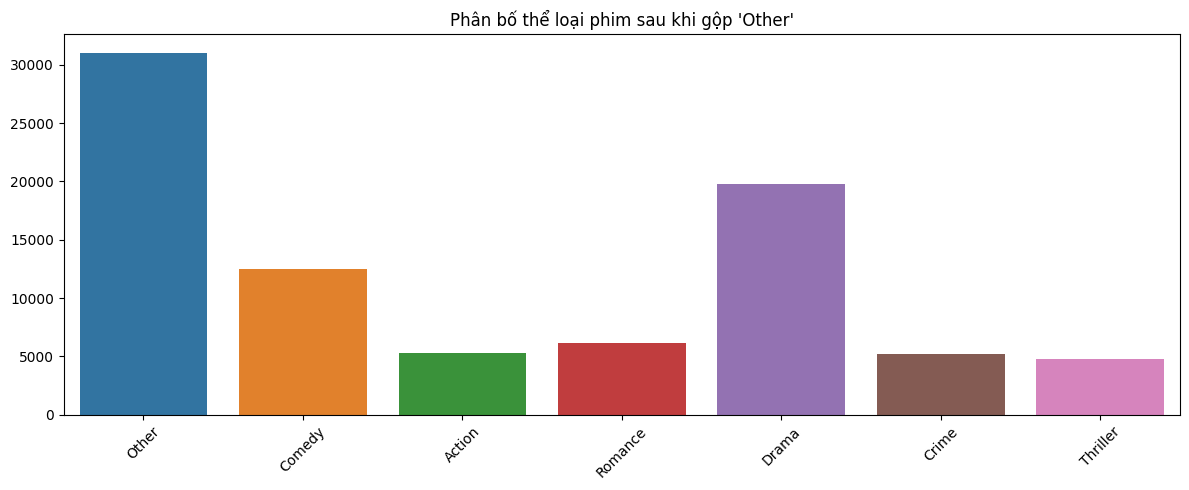

Số lượng thể loại sau khi gộp: 7
Các thể loại: ['Other', 'Comedy', 'Action', 'Romance', 'Drama', 'Crime', 'Thriller']


In [6]:
all_genres = [g for sub in df["Genre"] for g in sub]
genre_count = Counter(all_genres)
threshold = 4500
popular = [g for g, c in genre_count.items() if c >= threshold]
df["Genre"] = df["Genre"].apply(lambda xs: [g if g in popular else "Other" for g in xs])

merged_genre_count = Counter([g for sub in df["Genre"] for g in sub])
plt.figure(figsize=(12,5))
sns.barplot(x=list(merged_genre_count.keys()), y=list(merged_genre_count.values()))
plt.xticks(rotation=45)
plt.title("Phân bố thể loại phim sau khi gộp 'Other'")
plt.tight_layout()
plt.show()

print("Số lượng thể loại sau khi gộp:", len(merged_genre_count))
print("Các thể loại:", list(merged_genre_count.keys()))

In [7]:
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df["Genre"])
num_classes = Y.shape[1]
print("Classes:", list(mlb.classes_))
X_train_all, X_test, y_train_all, y_test = train_test_split(df["imdbId"], Y, test_size=0.2, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train_all, y_train_all, test_size=0.2, random_state=123, shuffle=True)
print("Train:", len(X_train), " Val:", len(X_val), " Test:", len(X_test))

Classes: ['Action', 'Comedy', 'Crime', 'Drama', 'Other', 'Romance', 'Thriller']
Train: 25049  Val: 6263  Test: 7828


In [8]:
tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class MovieDataset(Dataset):
    def __init__(self, ids, labels, img_dir, transform):
        self.ids = ids.reset_index(drop=True) if isinstance(ids, pd.Series) else pd.Series(ids)
        self.labels = labels
        self.img_dir = img_dir
        self.transform = transform
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        p = os.path.join(self.img_dir, f"{self.ids.iloc[idx]}.jpg")
        img = Image.open(p).convert("RGB")
        img = self.transform(img)
        return img, self.labels[idx], p

train_loader = DataLoader(MovieDataset(X_train, y_train, poster_dir, tf), batch_size=16, shuffle=True)
val_loader   = DataLoader(MovieDataset(X_val,   y_val,   poster_dir, tf), batch_size=16, shuffle=False)
test_loader  = DataLoader(MovieDataset(X_test,  y_test,  poster_dir, tf), batch_size=16, shuffle=False)

In [9]:
from torch.optim import Adam
from torch.nn import functional as F

tf_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

tf_val = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

ft_train_loader = DataLoader(
    MovieDataset(X_train, y_train, poster_dir, tf_train),
    batch_size=32, shuffle=True, num_workers=2, pin_memory=True
)
ft_val_loader = DataLoader(
    MovieDataset(X_val, y_val, poster_dir, tf_val),
    batch_size=32, shuffle=False, num_workers=2, pin_memory=True
)

backbone = models.densenet169(pretrained=True)
in_dim = backbone.classifier.in_features

head = nn.Sequential(
    nn.Linear(in_dim, 1024),
    nn.ReLU(inplace=True),
    nn.Dropout(0.6),
    nn.Linear(1024, 128),
    nn.ReLU(inplace=True),
    nn.Dropout(0.6),
    nn.Linear(128, num_classes)
)
backbone.classifier = head
backbone = backbone.to(device)

for param in list(backbone.features.children())[:-4]:
    for p in param.parameters():
        p.requires_grad = False

pos_counts = y_train.sum(axis=0)
neg_counts = (y_train.shape[0] - pos_counts)
pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-6),
                          dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = Adam(backbone.parameters(), lr=3e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

def run_epoch(model, loader, train=True):
    model.train(train)
    total, n = 0.0, 0
    for imgs, labels, _ in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = torch.tensor(labels, dtype=torch.float32, device=device)
        if train:
            optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss = criterion(logits, labels)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
        total += loss.item() * imgs.size(0)
        n += imgs.size(0)
    return total / max(n, 1)

epochs_ft = 20
best_val, wait, patience = float("inf"), 0, 5
best_state = None

print("Fine-tuning DenseNet-169")
for ep in range(1, epochs_ft + 1):
    tr_loss = run_epoch(backbone, ft_train_loader, train=True)
    with torch.no_grad():
        val_loss = run_epoch(backbone, ft_val_loader, train=False)
    scheduler.step()

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.cpu() for k, v in backbone.state_dict().items()}
        wait = 0
    else:
        wait += 1

    print(f"Epoch {ep:02d}: train_loss={tr_loss:.4f} | val_loss={val_loss:.4f}")
    if wait >= patience:
        print("Early stopping")
        break

if best_state is not None:
    backbone.load_state_dict({k: v.to(device) for k, v in best_state.items()})

backbone.classifier = nn.Identity()
backbone = backbone.to(device).eval()

@torch.no_grad()
def extract_embeddings(loader):
    embs, paths = [], []
    for imgs, _, ps in loader:
        imgs = imgs.to(device, non_blocking=True)
        feat = backbone(imgs)
        embs.append(feat.cpu().numpy())
        paths.extend(ps)
    return np.vstack(embs), paths

emb_tr,  paths_tr  = extract_embeddings(DataLoader(MovieDataset(X_train, y_train, poster_dir, tf_val), batch_size=16, shuffle=False))
emb_val, paths_val = extract_embeddings(DataLoader(MovieDataset(X_val,   y_val,   poster_dir, tf_val), batch_size=16, shuffle=False))
emb_te,  paths_te  = extract_embeddings(DataLoader(MovieDataset(X_test,  y_test,  poster_dir, tf_val), batch_size=16, shuffle=False))


Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth
100%|██████████| 54.7M/54.7M [00:00<00:00, 203MB/s]


Fine-tuning DenseNet-169
Epoch 01: train_loss=0.9564 | val_loss=0.8847
Epoch 02: train_loss=0.8841 | val_loss=0.8498
Epoch 03: train_loss=0.8454 | val_loss=0.8403
Epoch 04: train_loss=0.8178 | val_loss=0.8388
Epoch 05: train_loss=0.7994 | val_loss=0.8392
Epoch 06: train_loss=0.7954 | val_loss=0.8421
Epoch 07: train_loss=0.7932 | val_loss=0.8437
Epoch 08: train_loss=0.7874 | val_loss=0.8465
Epoch 09: train_loss=0.7782 | val_loss=0.8527
Early stopping


In [10]:
yolo = YOLO("/kaggle/input/yolov8-small/yolov8s.pt")
n_obj = len(yolo.names)

def extract_yolo_from_paths(paths):
    out = []
    for p in paths:
        r = yolo(p, device=0, verbose=False)[0]
        v = np.zeros(n_obj, dtype=np.float32)
        if r.boxes is not None and len(r.boxes) > 0:
            cls = r.boxes.cls.cpu().numpy().astype(int)
            conf = r.boxes.conf.cpu().numpy()
            for c, cf in zip(cls, conf):
                v[c] += float(cf)
        v = np.clip(v, 0, 1)
        out.append(v)
    return np.vstack(out)

yolo_tr  = extract_yolo_from_paths(paths_tr)
yolo_val = extract_yolo_from_paths(paths_val)
yolo_te  = extract_yolo_from_paths(paths_te)

In [11]:
print("DenseNet embedding shape (train):", emb_tr.shape) 
print("YOLO features shape (train):", yolo_tr.shape) 
D_densenet = emb_tr.shape[1]
D_yolo = yolo_tr.shape[1]
print(f"DenseNet dim = {D_densenet}, YOLO dim = {D_yolo}, total = {D_densenet + D_yolo}")

DenseNet embedding shape (train): (25049, 1664)
YOLO features shape (train): (25049, 80)
DenseNet dim = 1664, YOLO dim = 80, total = 1744


In [12]:
feat_tr  = np.hstack([emb_tr,  yolo_tr])
feat_val = np.hstack([emb_val, yolo_val])
feat_te  = np.hstack([emb_te,  yolo_te])

scaler = StandardScaler()
feat_tr_sc  = scaler.fit_transform(feat_tr)
feat_val_sc = scaler.transform(feat_val)
feat_te_sc  = scaler.transform(feat_te)

lgbm_fs = OneVsRestClassifier(
    LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42
    ),
    n_jobs=-1
)

lgbm_fs.fit(feat_tr_sc, y_train)
all_gain = np.vstack([
    est.booster_.feature_importance(importance_type="gain")
    for est in lgbm_fs.estimators_
])

mean_gain = all_gain.mean(axis=0)
threshold = np.median(mean_gain)
selected_mask = mean_gain > threshold

print("Số feature sau Feature Selection:", selected_mask.sum())

X_tr_fs  = feat_tr_sc[:, selected_mask]
X_val_fs = feat_val_sc[:, selected_mask]
X_te_fs  = feat_te_sc[:, selected_mask]

[LightGBM] [Info] Number of positive: 7968, number of negative: 17081
[LightGBM] [Info] Number of positive: 3383, number of negative: 21666
[LightGBM] [Info] Number of positive: 3329, number of negative: 21720
[LightGBM] [Info] Number of positive: 12715, number of negative: 12334
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.333926 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 370094
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.222247 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 370094
[LightGBM] [Info] Number of data points in the train set: 25049, number of used features: 1530
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.318097 -> initscore=-0.762533
[LightGBM] [Info] Start training from score -0.762533
[LightGBM] [Info] Number of data points in the train set: 25049, number of used features: 1530

In [13]:
cls_freq = y_train.sum(axis=0).astype(np.float64) + 1e-6
inv_cls = 1.0 / cls_freq

sample_w = (y_train * inv_cls).sum(axis=1) / np.maximum(y_train.sum(axis=1), 1)
sample_w = sample_w / (sample_w.mean() + 1e-12)

multiplier = 2.0
n_extra = int((multiplier - 1.0) * len(X_tr_fs))
idx_extra = np.random.choice(len(X_tr_fs), size=n_extra, replace=True, p=sample_w / sample_w.sum())

X_tr_os = np.vstack([X_tr_fs, X_tr_fs[idx_extra]])
y_tr_os = np.vstack([y_train, y_train[idx_extra]])

print("Oversample:", X_tr_os.shape, y_tr_os.shape)


Oversample: (50098, 872) (50098, 7)


In [14]:
lgbm = OneVsRestClassifier(
    LGBMClassifier(
        n_estimators=1200,
        learning_rate=5e-4,
        num_leaves=128,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=2.0,
        random_state=42
    ), n_jobs=-1
)
lgbm.fit(X_tr_os, y_tr_os)

val_probs = lgbm.predict_proba(X_val_fs)
test_probs = lgbm.predict_proba(X_te_fs)

[LightGBM] [Info] Number of positive: 8589, number of negative: 41509
[LightGBM] [Info] Number of positive: 24558, number of negative: 25540
[LightGBM] [Info] Number of positive: 8671, number of negative: 41427
[LightGBM] [Info] Number of positive: 16021, number of negative: 34077
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.726140 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 222360
[LightGBM] [Info] Number of data points in the train set: 50098, number of used features: 872
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.171444 -> initscore=-1.575428
[LightGBM] [Info] Start training from score -1.575428
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.672537 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 222360
[LightGBM] [Info] Number of data points in the train set: 50098, number of used features: 872


In [15]:
def tune_thresholds(probs, y_true, beta=1.0):
    ths = []
    for i in range(y_true.shape[1]):
        p, r, thr = precision_recall_curve(y_true[:, i], probs[:, i])
        f = (1+beta**2)*p*r/(beta**2*p + r + 1e-12)
        j = int(np.nanargmax(f))
        t = thr[j-1] if j>0 and (j-1)<len(thr) else 0.5
        ths.append(float(np.clip(t, 0.01, 0.9)))
    return np.array(ths, dtype=np.float32)

best_th = tune_thresholds(val_probs, y_val, beta=1.0)
print("Threshold per-class:", np.round(best_th, 3).tolist())

Threshold per-class: [0.2240000069141388, 0.3140000104904175, 0.17900000512599945, 0.4180000126361847, 0.4480000138282776, 0.19099999964237213, 0.1850000023841858]


In [16]:
order = np.argsort(-test_probs, axis=1)
K_prior = float(y_train.sum(axis=1).mean())
K = max(1, int(np.round(K_prior))) 
y_pred = np.zeros_like(test_probs, dtype=int)

for i in range(test_probs.shape[0]):
    picked = []
    for j in order[i]:
        if test_probs[i, j] >= best_th[j]:
            picked.append(j)
        if len(picked) == K:
            break
    if len(picked) == 0:
        picked = [order[i, 0]]
    y_pred[i, picked] = 1

In [17]:
from sklearn.metrics import jaccard_score

print(f"Precision (micro): {precision_score(y_test, y_pred, average='micro', zero_division=0):.2f}")
print(f"Recall (micro): {recall_score(y_test, y_pred, average='micro', zero_division=0):.2f}")
print(f"F1-score (micro): {f1_score(y_test, y_pred, average='micro', zero_division=0):.2f}")
print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"Recall (macro): {recall_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"F1-score (macro): {f1_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"Hamming Loss: {hamming_loss(y_test, y_pred):.2f}")

acc_label = accuracy_score(y_test.flatten(), y_pred.flatten())
print(f"Accuracy (per-label): {acc_label:.2f}")

def at_least_one_accuracy(y_true, y_pred):
    correct = 0
    for t, p in zip(y_true, y_pred):
        if np.sum(t * p) > 0:
            correct += 1
    return correct / len(y_true)
alo_acc = at_least_one_accuracy(y_test, y_pred)
print(f"At-least-one Accuracy: {alo_acc:.2f}")

jaccard = jaccard_score(y_test, y_pred, average='samples', zero_division=0)
print(f"Jaccard per-sample: {jaccard:.2f}")

Precision (micro): 0.60
Recall (micro): 0.61
F1-score (micro): 0.61
Precision (macro): 0.51
Recall (macro): 0.41
F1-score (macro): 0.42
Hamming Loss: 0.22
Accuracy (per-label): 0.78
At-least-one Accuracy: 0.91
Jaccard per-sample: 0.49


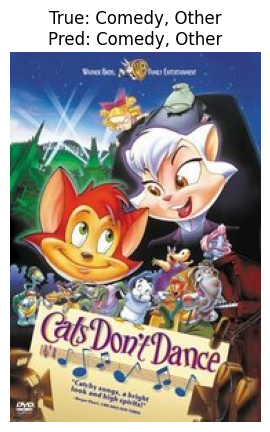

In [18]:
idx = random.randint(0, len(X_test)-1)
imdb_id = X_test.values[idx]
true_genres = mlb.inverse_transform(np.array([y_test[idx]]))[0]
pred_genres = mlb.inverse_transform(np.array([y_pred[idx]]))[0]

img = Image.open(os.path.join(poster_dir, f"{imdb_id}.jpg")).convert("RGB")
plt.imshow(img); plt.axis("off")
plt.title(f"True: {', '.join(true_genres)}\n"f"Pred: {', '.join(pred_genres)}")
plt.show()